In [1]:
from __future__ import annotations
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from pathlib import Path
import dataretrieval.nwis as nwis
import dataretrieval.waterdata as waterdata
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynhd as nhd
from pynhd import NLDI, NHDPlusHR, WaterData
import py3dep
import pygeohydro as gh
from pathlib import Path
import networkx as nx
import xarray as xr
import xrspatial
import os
from scripts import maps, data, dataprocessing, SNOTEL_Analyzer, files, catchment, stream_analysis


In [2]:
#Initialize names and parameters

nldi = NLDI()
station = '09114500' #GUNNISON RIVER above blue mesa reservoir
WY = 2025 #2025 water year ends on oct 1 2025, so the DOI falles within this water year

basin = nldi.get_basins(station)
basinname = 'BlueMesaReservoir'
geometry = basin.geometry.iloc[0]
watershed = "Upper Gunnison"
AOI = 'Above Blue Mesa Reservoir'
DOI = '04-01'

## Make data files

In [3]:
#Basin File
site_feature, upstream_network = files.basinFile(basin, basinname, station)

#SNOTEL File
snotel = files.snotelFile(geometry,'CO')

#Streamflow File
discharge = files.dischargeFile(station)

done
Start retrieving data for Butte, 380_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/380:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-30/WTEQ::value?fitToScreen=false
Start retrieving data for Park Cone, 680_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/680:CO:SNTL%7Cid=%22%22%7Cname/1979-10-01,2026-03-30/WTEQ::value?fitToScreen=false
Start retrieving data for Upper Taylor, 1141_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/1141:CO:SNTL%7Cid=%22%22%7Cname/2009-08-26,2026-03-30/WTEQ::value?fitToScreen=false
Retrieving data for Site: 09114500 from 1980-01-01 to 2025-04-02...


# 1. Area of Interest

### Watershed Map with stream gauge and SNOTEL icons 

In [116]:
maps.snotel_mapping(snotel, basin, site_feature)

### Catchment Characteristics

In [4]:
#Get information for Figures/future Dataframes

#Flowlines for the mainstem of the station
flw_main = catchment.nldi_info(station,"upstreamMain",'flowlines')

#Flowlines for the Tributaries of the station
flw_trib = catchment.nldi_info(station,'upstreamTributaries','flowlines')

#Get the stations for the upstream of the station within 1000 km
st_all = catchment.nldi_info(station,'upstreamTributaries','nwissite')

#List of active station ids 
st_active = catchment.active(st_all)

#Flow points where HUC12 boundaries intersect with the flowlines for the tributaries of the station
pp = catchment.nldi_info(station,'upstreamTributaries','huc12pp')


/opt/homebrew/Caskroom/miniforge/base/envs/hyriver/lib/python3.10/site-packages/dataretrieval/nwis.py:692: UserWarning: WARNING: Starting in March 2024, the NWIS qw data endpoint is retiring and no longer receives updates. For more information, refer to https://waterdata.usgs.gov.nwis/qwdata and https://doi-usgs.github.io/dataRetrieval/articles/Status.html or email CompTools@usgs.gov.
  warnings.warn(


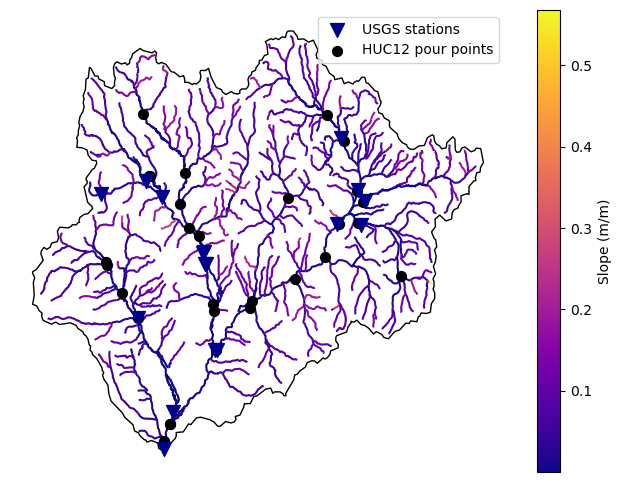

In [5]:
#Slope
slope = catchment.slope(flw_trib)

#Plot the slope attribute for the flowlines of the tributaries of the station
ax = basin.plot(facecolor="none", edgecolor="k", figsize=(8, 6))
slope.plot(
    ax=ax,  
    column="slope",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Slope (m/m)"},
)

st_active.plot(
    ax=ax,
    label="USGS stations",
    marker="v",
    markersize=100,
    zorder=5,
    color="darkblue",
)
pp.plot(ax=ax, label="HUC12 pour points", marker="o", markersize=50, color="k", zorder=3)

ax.legend(loc="best")
ax.set_aspect("auto")
ax.set_axis_off()
ax.figure.set_dpi(100)

ax.set_axis_off()

fig = ax.get_figure()
fig.savefig("figures/slope_attrib.png", bbox_inches="tight", facecolor="w")

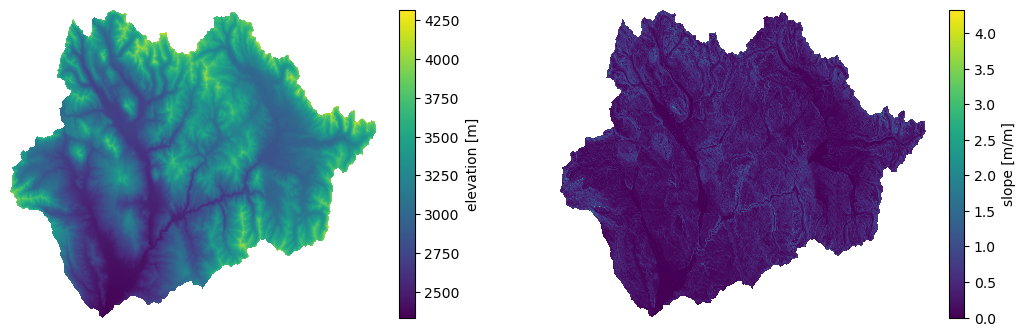

In [6]:
#Topography

topo = catchment.DEM(geometry,station)

fig, axs = plt.subplots(ncols=2, figsize=(13, 4))
topo['elevation'].plot(ax=axs[0])
topo['slope'].plot(ax=axs[1])
for ax in axs:
    ax.set_title("")
    ax.set_axis_off()
fig.savefig("Figures/dem_slope.png", bbox_inches="tight", facecolor="w")

### Land Cover

In [7]:
#Initial basin dataframe (elevation,slope,area)
temp_info = catchment.basin_dataframe(topo,geometry,basinname,basin,station)

In [14]:
#List of data years after I had an error, so most recent info is 2021
# cover: 2021, 2019, 2016, 2013, 2011, 2008, 2006, 2004, 2001
# canopy: 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021
# descriptor: 2021, 2019, 2016, 2013, 2011, 2008, 2006, 2004, 2001

descript = gh.nlcd_bygeom(basin.geometry, 100, years={"descriptor": 2021}, ssl=False)
lulcover = gh.nlcd_bygeom(basin.geometry, 100, years={"cover": [2019, 2021]}, ssl=False)

stats = gh.cover_statistics(lulcover[f"USGS-{station}"].cover_2021) # Get the land cover statistics 
roughness = gh.overland_roughness(lulcover[f"USGS-{station}"].cover_2021) # Get the overland flow roughness


In [16]:
#Create map for Land Cover
cmap, norm, levels = gh.plot.cover_legends()
cover = lulcover[f"USGS-{station}"].cover_2021 
unique = np.unique(cover.values)

nlcd_legend = {
    11: "Open Water",
    12: "Perennial Ice/Snow",
    21: "Developed, Open Space",
    22: "Developed, Low Intensity",
    23: "Developed, Medium Intensity",
    24: "Developed, High Intensity",
    31: "Barren Land (Rock/Sand/Clay)",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland/Herbaceous",
    90: "Woody Wetlands",
    95: "Emergent Herbaceous Wetlands",
    127: "No Data / Masked"
}

unique = [nlcd_legend.get(code, "Unknown") for code in unique]

In [17]:
def map_names(val):
    return nlcd_legend.get(val, "Unknown")

v_map_names = np.vectorize(map_names) 
cover_names = xr.apply_ufunc(v_map_names, cover)
vals, counts = np.unique(cover.values, return_counts=True)

# Summary DataFrame
summary = pd.DataFrame({
    "code": vals,
    "count": counts,
    "name": [nlcd_legend.get(v, "Unknown") for v in vals]
})

# Calculate Percentage
total_pixels = summary[summary['code'] != 127]['count'].sum()
summary['percent'] = (summary['count'] / total_pixels) * 100
summary = summary[summary['code'] != 127]

lulcover = summary.copy()
lulcover = lulcover.drop(columns=["count", "code"])
lulcover.head()

lulcover.rename(columns={"name": "Basin_Name", 'percent': temp_info['Basin_Name'].values[0]}, inplace=True)
lulcover.set_index("Basin_Name", inplace=True)

lulcover = lulcover.T
lulcover.columns = lulcover.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("/", "_")

#Combine into final summary
temp_info.set_index('Basin_Name', inplace=True)
basin_info = pd.concat([temp_info, lulcover], axis=1)

OutputFolder = 'files/basin_info'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
basin_info.to_csv(f'{OutputFolder}/basin_info_{station}.csv')

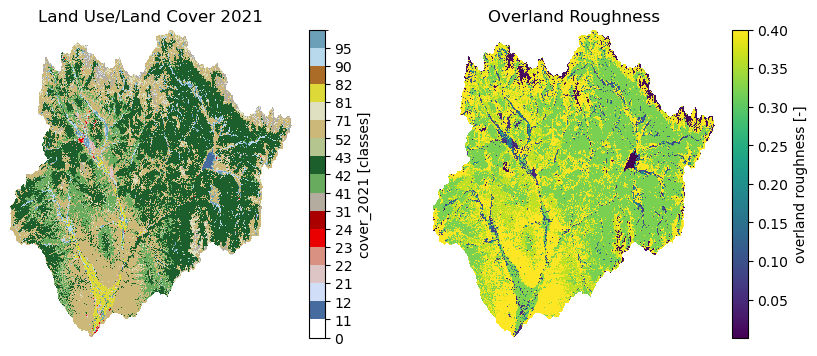

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cover.where(cover < 127).plot(ax=ax1, cmap=cmap, levels=levels, cbar_kwargs={"ticks": levels[:-1]})
ax1.set_title("Land Use/Land Cover 2021")
ax1.set_axis_off()

roughness.plot(ax=ax2)
ax2.set_title("Overland Roughness")
ax2.set_axis_off()
fig.savefig(Path("Figures", "lulc.png"), bbox_inches="tight", facecolor="w")

### Catchment Summary 

In [20]:
basin_info

,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,Area_km2,Open_Water,Perennial_Ice_Snow,"Developed,_Open_Space","Developed,_Low_Intensity",...,"Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Unknown,Woody_Wetlands,Emergent_Herbaceous_Wetlands
BlueMesaReservoir,09114500,3111.5432,2333.7517,4320.204,0.29461083,4318.068667,0.328748,0.262315,0.663189,0.218659,...,0.020879,2.377156,11.094281,41.575559,1.98767,30.559099,3.65874,1.961097,3.289374,1.882516


# 2. SWE Analysis for Snotel 

### Sites descriptions 

In [21]:
snotel

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,380_CO_SNTL,Butte,SNOTEL,3096.768066,38.894329,-106.953003,Colorado,140200010206,13SCD,Southern Rocky Mountains,1979-10-01,2026-03-30,True,POINT (-106.953 38.89433)
1,680_CO_SNTL,Park Cone,SNOTEL,2926.080078,38.819962,-106.589737,Colorado,140200010107,13SCC,Southern Rocky Mountains,1979-10-01,2026-03-30,True,POINT (-106.58974 38.81996)
2,1141_CO_SNTL,Upper Taylor,SNOTEL,3243.072021,38.990768,-106.754219,Colorado,140200010101,13SCD,Southern Rocky Mountains,2009-08-26,2026-03-30,True,POINT (-106.75422 38.99077)


### Historical Comparison

In [4]:

# Load the data for one site
sites = list(snotel.code)
print(sites)
stateab = 'Co'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

['380_CO_SNTL', '680_CO_SNTL', '1141_CO_SNTL']
380_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
680_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
1141_CO_SNTL
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


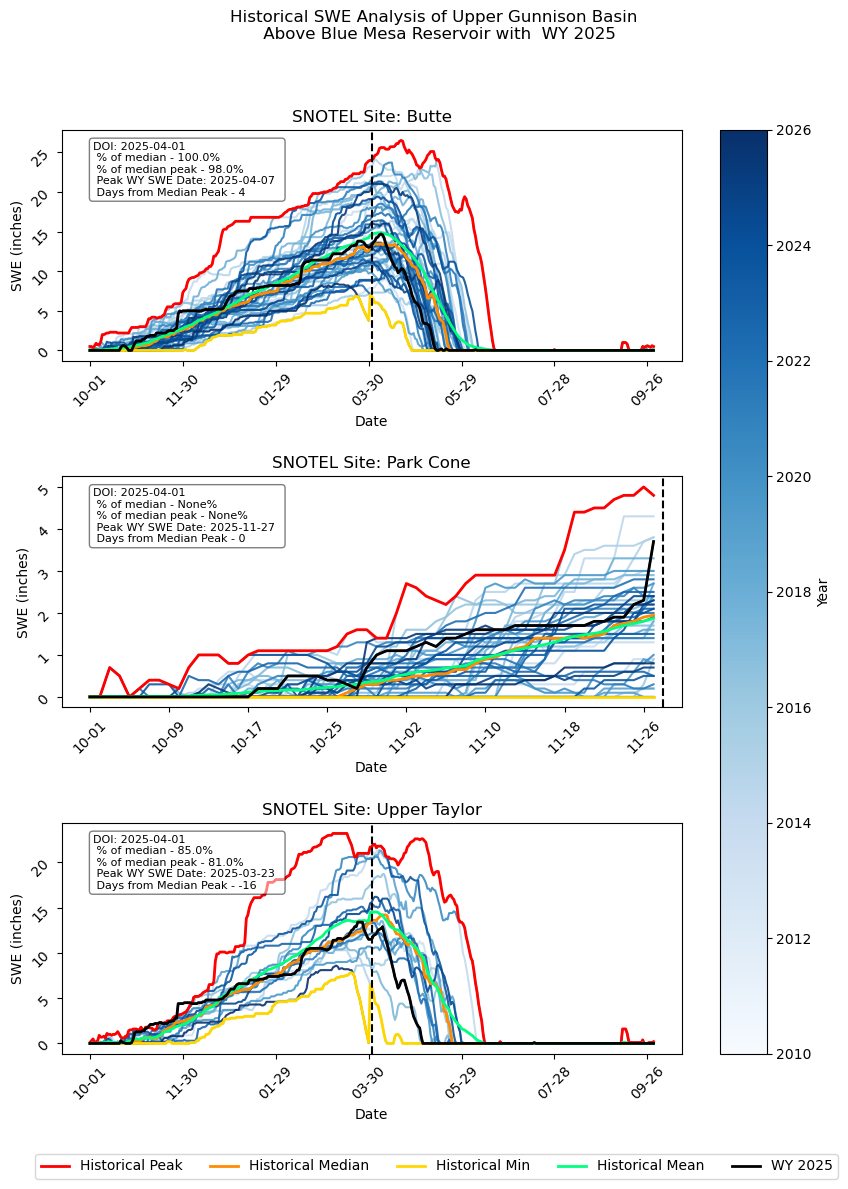

In [5]:
SNOTEL_Analyzer.year_Plots(sitedict,snotel,WY, watershed, AOI,DOI)

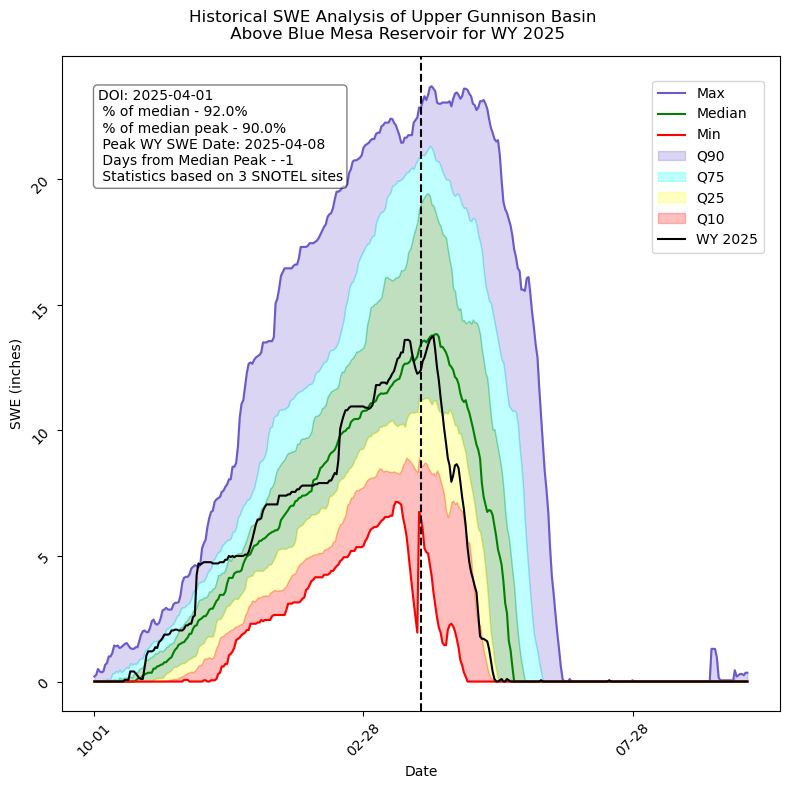

In [6]:
catchmentswe = SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

# 3. Streamflow Analysis

### Location Information 

In [25]:
info, met = waterdata.get_monitoring_locations(monitoring_location_id= f"USGS-{station}")
info = info.T.dropna()
info.head(45)

,0
monitoring_location_id,USGS-09114500
geometry,POINT (-106.9497661258 38.5419356710082)
agency_code,USGS
agency_name,U.S. Geological Survey
monitoring_location_number,09114500
monitoring_location_name,"GUNNISON RIVER NEAR GUNNISON, CO."
district_code,08
country_code,US
country_name,United States of America
state_code,08


### Historical Comparison for April-September of Streamflow Volume (m^3)

In [5]:
#Clean up data and include water-year column
streamflow = discharge.drop(columns=['site_no']).copy()
streamflow.rename(columns={'flow_cms':'Flow (cms)'}, inplace=True)
streamflow["Flow Volume (m^3)"] = streamflow['Flow (cms)'] *60*60*24
streamflow = streamflow.drop(columns=['Flow (cms)'])
streamflow.reset_index(inplace=True)
# streamflow['Date'] = pd.to_datetime()

In [19]:
streamflow.head()

,Flow Volume (m^3)
Date,
1980-01-01,587177.1648
1980-01-02,587177.1648
1980-01-03,611642.8800
1980-01-04,636108.5952
1980-01-05,636108.5952


In [6]:
processed = stream_analysis.process_stream(streamflow, WY)

Dropping 2025 from the calculations of the min, mean, median, max Flow Volume for each day of the water year across all other years of data available


In [26]:
processed.index

DatetimeIndex(['2023-04-01', '2023-04-02', '2023-04-03', '2023-04-04',
               '2023-04-05', '2023-04-06', '2023-04-07', '2023-04-08',
               '2023-04-09', '2023-04-10',
               ...
               '2023-10-23', '2023-10-24', '2023-10-25', '2023-10-26',
               '2023-10-27', '2023-10-28', '2023-10-29', '2023-10-30',
               '2023-10-31',        'NaT'],
              dtype='datetime64[ns]', name='date', length=215, freq=None)

ConversionError: Failed to convert value(s) to axis units: '04-01'

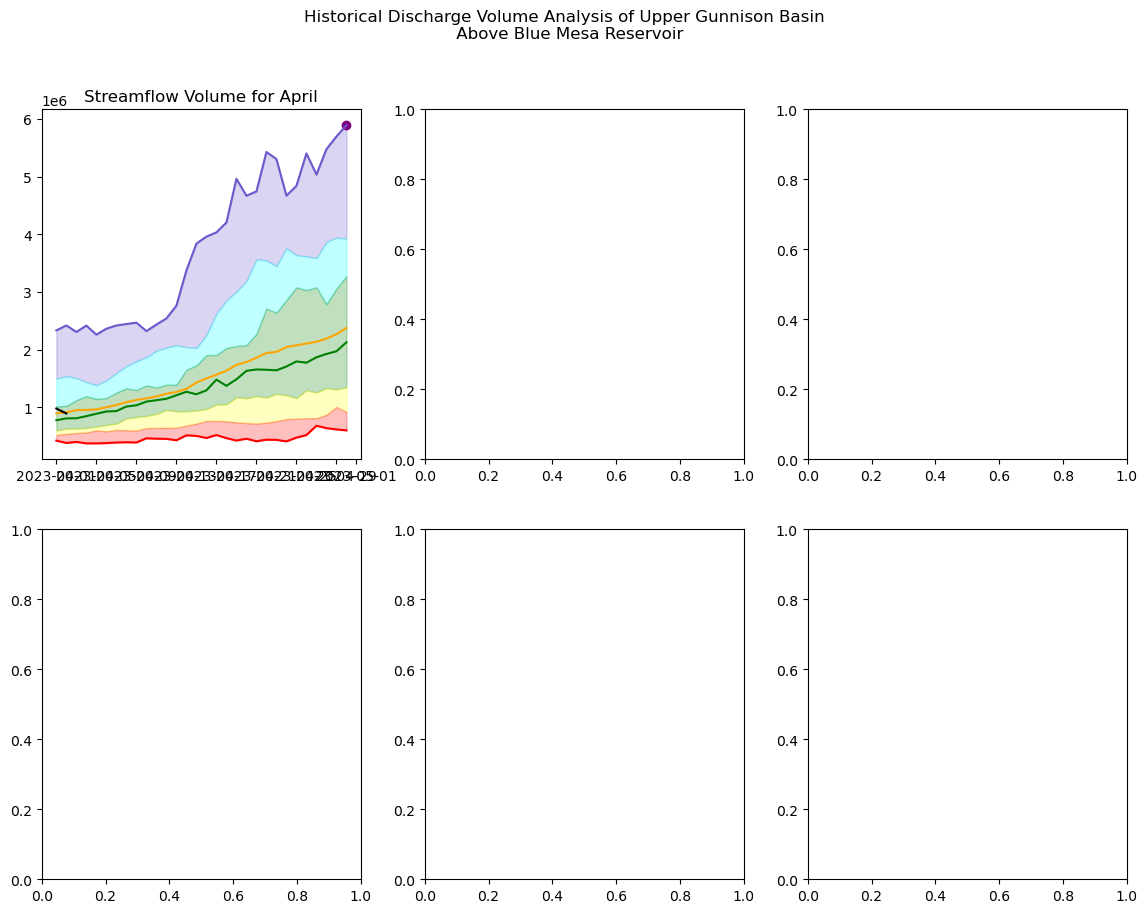

In [7]:
stream_analysis.StreamPlots(processed, WY, watershed, AOI,DOI)

# 4. Peak Parity with Volumetric Streamflow April-September

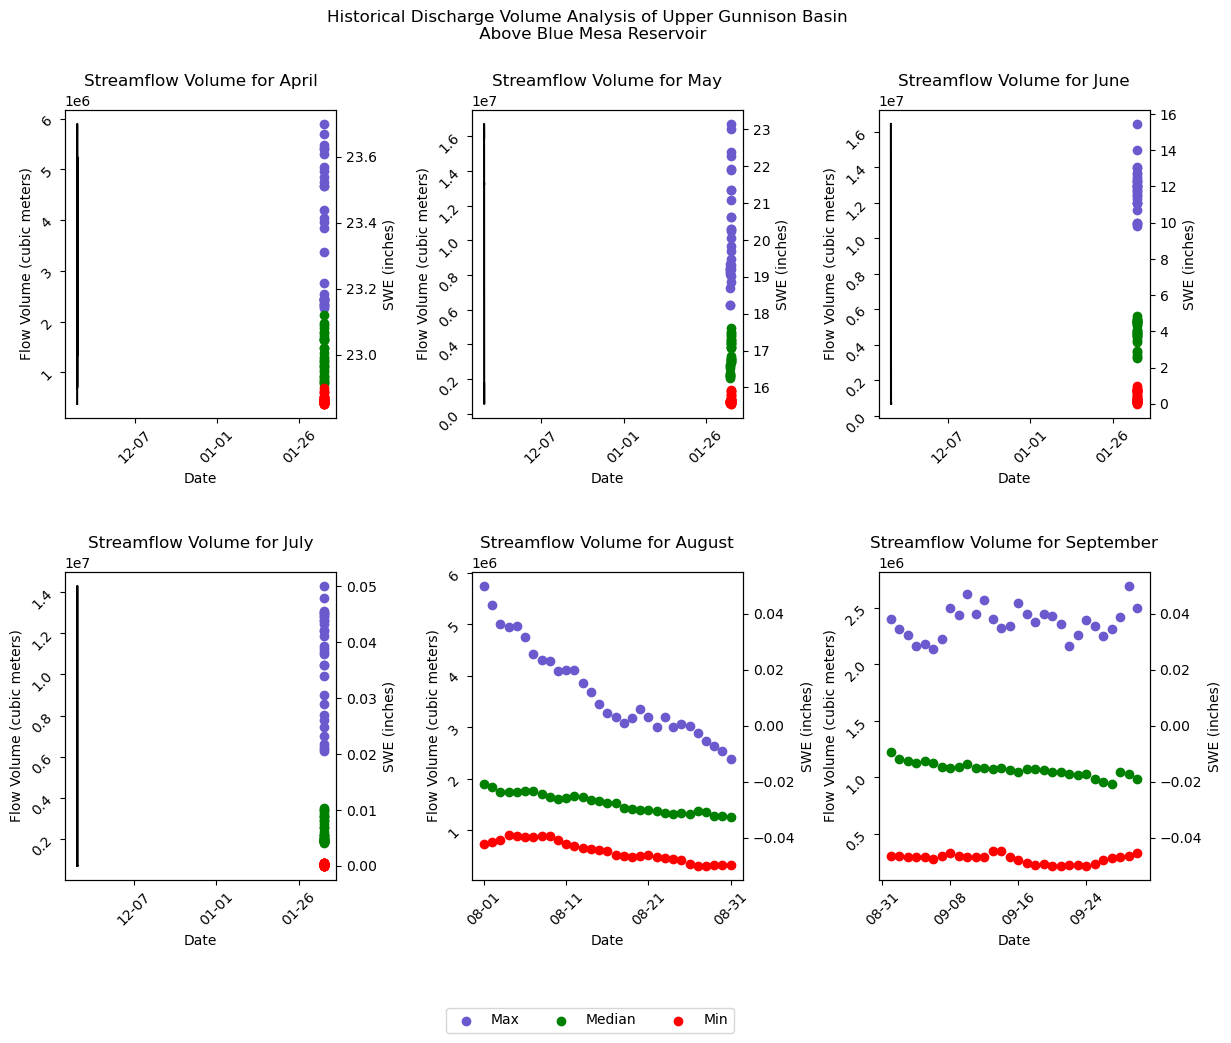

In [10]:
stream_analysis.SWE_Stream_Comparison(processed,catchmentswe,WY,watershed,AOI)

23.700012798000003
23.150012501
15.450008343
0.050000027
nan


ValueError: Axis limits cannot be NaN or Inf

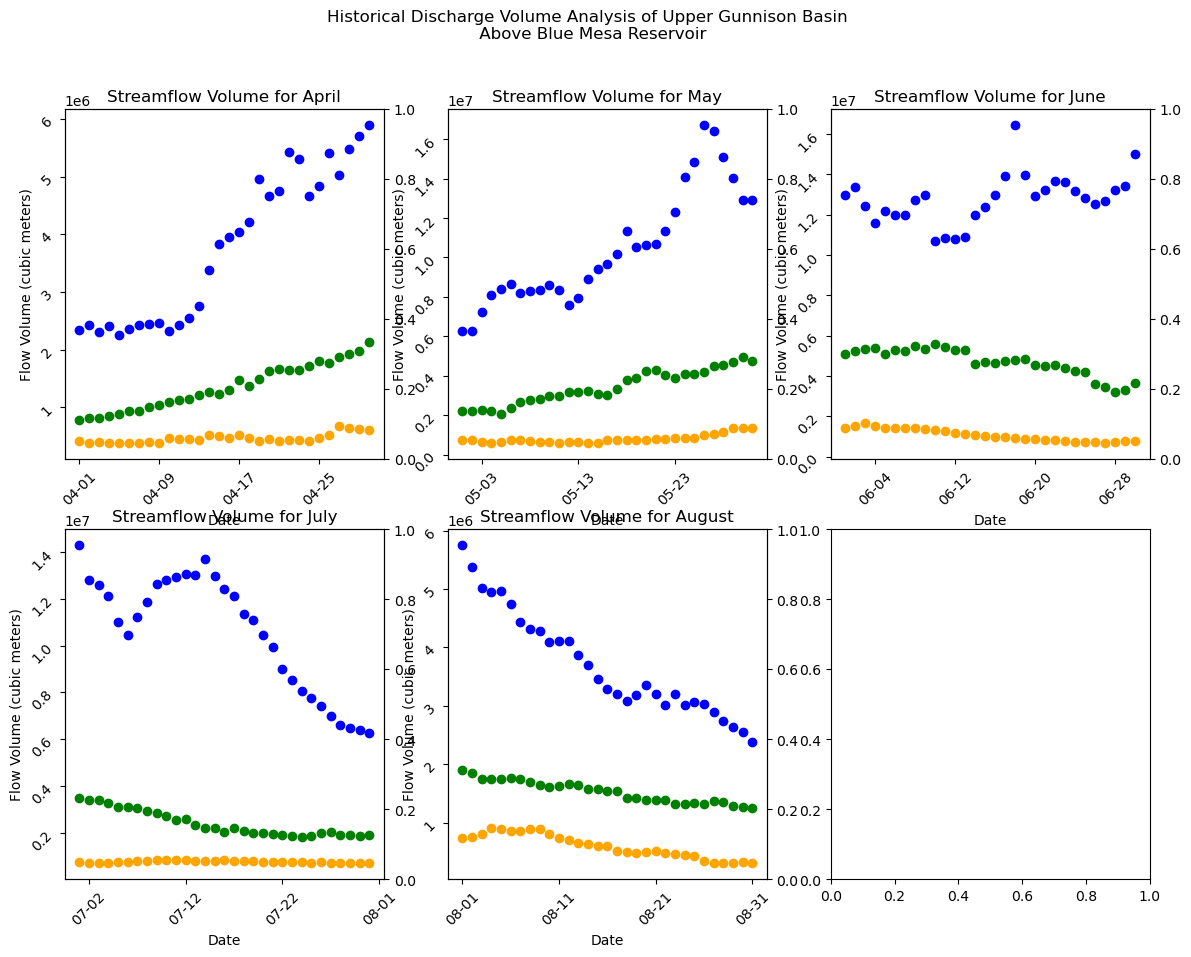

In [46]:
monthdict = {1:("April",4),2:("May",5),3:("June",6),4:("July",7),5:("August",8),6:("September",9)}

title = f'Historical Discharge Volume Analysis of {watershed} Basin \n {AOI}'
fig, axs = plt.subplots(2, 3, figsize = (14, 10))
fig.suptitle(title)
opacity = 0.25
WYOI = f"{WY} Flow Volume (m^3)"

axs = axs.ravel()
for i, key in enumerate(monthdict.keys()):
    df = processed[processed['M']== monthdict[key][1]]
    catchment = catchmentswe[catchmentswe.index.month == monthdict[key][1]]
    print(catchment['max'].max())
    #Plot SWE Peak line from Catchment summary to show historical peak SWE

    #Plot streamflow values as scatterplots to match the Parity Plot Requirement
    axs[i].set_title(f"Streamflow Volume for {monthdict[key][0]}")
    #check dataframe for respective water year
    if f"{WY} Flow Volume (m^3)" in df.columns:
        #key swe lines on SNOTEL plot
        axs[i].scatter(df.index, df['max'], color = 'blue', label = 'Max')
        axs[i].scatter(df.index,df['median'], color = 'green', label = 'Median')
        axs[i].scatter(df.index,df['min'], color = 'orange', label = 'Min')

        axs[i].xaxis.set_major_locator(ticker.MaxNLocator(4))
        axs[i].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        axs[i].tick_params(labelrotation=45)
        handles, labels = axs[i].get_legend_handles_labels()

    else:
        axs[i].annotate('No Data', xy=(0.45, 0.45), xytext=(0.45, 0.45))

# Set axis labels
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Flow Volume (cubic meters)')

    if catchment['max'].notna().all():
        axs2 = axs[i].twinx()
        ax2.plot(catchment.index, catchment['max'], color='black', linewidth=2)
        ax2.set_ylim(catchment['max'].min(),catchment['max'].max())

    else:
        pass
 
fig.subplots_adjust( hspace=0.5,wspace=0.5)        
fig.legend(handles, labels,loc='lower center',ncol=8, bbox_to_anchor=(.5, -.05))
plt.show()